Example notebook to generate Fig. 8 (DESI DR1 TFR) for the DR1 TF paper.

In [1]:
from astropy.io import fits
from astropy.cosmology import FlatLambdaCDM

import numpy as np

import matplotlib.pyplot as plt

In [2]:
cosmo = FlatLambdaCDM(H0=100, Om0=0.3151)

# Data

## Galaxies

In [3]:
hdul = fits.open('fig8_data.fits')

gals = hdul[1].data

hdul.close()

In [4]:
main = gals['MAIN']

is_cal = gals['CAL']

## Calibrated TFR

In [5]:
hdul = fits.open('../Fig7/fig7_data.fits')

hdr = hdul[0].header
mcmc_samples = hdul[0].data

hdul.close()

In [6]:
logV0 = hdr['LOG_V0']

slope = np.median(mcmc_samples[0])

zc = 0.5*0.005 + np.arange(0.03, 0.099, 0.005)
mu_zc = cosmo.distmod(zc)
ZP = np.median(mcmc_samples[1:-1], axis=1) - mu_zc.value

sig = np.median(mcmc_samples[-1])

# Plot

In [7]:
logv = np.linspace(-1*np.ones(14), 3.5*np.ones(14), 100)

absmag = slope*(logv - logV0) + ZP

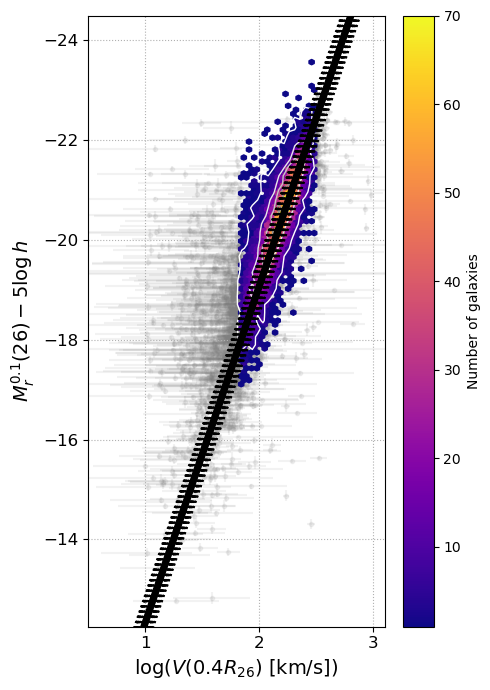

In [8]:
plt.figure(figsize=(5,7), tight_layout=True)

plt.grid(ls=':')

plt.errorbar(np.log10(gals['VROT'][~main]), 
             gals['R_ABSMAG'][~main], 
             xerr=0.434*gals['VROT_ERR'][~main]/gals['VROT'][~main],
             yerr=gals['R_ABSMAG_ERR'][~main], 
             fmt='.',
             color='gray',
             alpha=0.1, 
             ecolor='gray', 
             zorder=1)

plt.hexbin(np.log10(gals['VROT'][main]), 
           gals['R_ABSMAG'][main], 
           cmap='plasma', 
           mincnt=1, 
           vmin=1, 
           vmax=70, 
           gridsize=(70,80), 
           extent=(-0.1, 3.1, -25, -12.25), 
           zorder=2)

plt.colorbar(label='Number of galaxies')

_N, _edges_x, _edges_y = np.histogram2d(np.log10(gals['VROT'][is_cal]), 
                                        gals['R_ABSMAG'][is_cal], 
                                        bins=(np.linspace(-0.1, 3.1, 70), 
                                              np.linspace(-25, -12.25, 80)))
_mesh_x, _mesh_y = np.meshgrid(_edges_x[:-1], _edges_y[:-1], indexing='ij')
plt.contour(_mesh_x, _mesh_y, _N, 
            levels=np.linspace(3, 150, 7), 
            linewidths=1, 
            cmap='Grays', 
            zorder=3)

plt.plot(logv, absmag, 'k', zorder=3)
plt.plot(logv, absmag + sig, 'k:', zorder=4)
plt.plot(logv, absmag - sig, 'k:', zorder=5)

plt.xlim([0.5, 3.1])
plt.ylim([-12.25, -24.5])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r^{0.1} (26) - 5\log h$', fontsize=14);

ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=12);